## CNN for Fossil Classification

In [5]:
# Import dependencies
import numpy as np 
import keras
from keras import layers
import tensorflow_datasets as tfds
from tensorflow import data as tf_data
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from skimage import io
import pandas as pd

In [6]:
# You don't need this unless you are using google colab - this was to get my data to read
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First, we import and split the data into testing, training, and validation sets. This should be written as a function so we can test on different folds during cross validation, where we will tune hyperparameters. 

In [7]:
# This file path will need to change
image_samples = pd.read_csv("/content/drive/MyDrive/MLGeoProject/ImageSamples.csv")
header_name = 'samples'

# Takes in a list of samples (csv) and a target opb, opc, etc and returns a random sample as a string
def GetRandomThinSections(target, samplelist, headername):
    target = str(target)

    # Filter list of samples so we only deal with those involving target
    filtered_samples = samplelist[samplelist[headername].str.contains(target)]
    
    #randomly select one row (ie one thin section)
    if not filtered_samples.empty:
        random_thin_section = filtered_samples.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    else:
        print(f"No rows found with '{target}' in 'samples'")
    return random_thin_section


In [8]:
#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data
def TrainTestValSplit(image_folder, sections):
    #image_folder = input_patches
    # randomly select a thin section (thin_section_nums)
    #thin_sections = random.sample(thin_section_nums, num_sections)
    #thin_sections = [str(ts) for ts in thin_sections]

    # Initialize empty lists
    test_data_names = []
    validation_data_names = []
    training_data_names = []
    remaining_data_names = []
    remaining_data = []
    test_data = []
    train_data = []
    val_data = []

    # Loop through targets to pull one random thin section and add to test data
    for section in sections:
        # Add thin sections corresponding to random choice to test data, then split remaining data into test and validation sets
        for filename in os.listdir(image_folder):
            if filename.lower().endswith((".jpg", ".png", ".jpeg")):
                filepath = os.path.join(image_folder, filename)
            if section in filename:
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)
    # We now have the names of the files we want.
    # Now, split remaining data into training and validation sets at random
    print(test_data_names)
    random.shuffle(remaining_data_names) #randomly shuffles remaining image patches
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]

    # Read in images to add to data
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    #Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

# Change file paths depending on your data - note that fossils but not centered and center fossils are classified as being fossil posiive here
center_folder = "/content/drive/MyDrive/MLGeoProject/Center_Fossil"
fossil_nocenter_folder = "/content/drive/MyDrive/MLGeoProject/No_Center_Fossil"
no_fossil_folder = "/content/drive/MyDrive/MLGeoProject/No_Fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]
sections = []

#This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
for target in targets:
    test_section = GetRandomThinSections(target, image_samples, header_name)
    sections.append(test_section)
print("Sections Isolated for Testing:")
print(sections)

train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

# Now, get label data setting fossils to 1 and no fossil to 0

Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

Sections Isolated for Testing:
['opb_19.2', 'opc_64.1', 'opd_49.0', 'ope_58.0', 'opf_51.0']
['/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2c_patch2.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2e_patch3.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2b_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2b_patch5.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2e_patch2.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opb_19.2b_patch3.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_ope_58.0b_patch2.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_ope_58.0a_patch3.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_ope_58.0a_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_ope_58.0a_patch2.png']
['/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opb_19.2c_patch5.png', '

In [9]:
# Transform numpy arrays to tf datasets

training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))


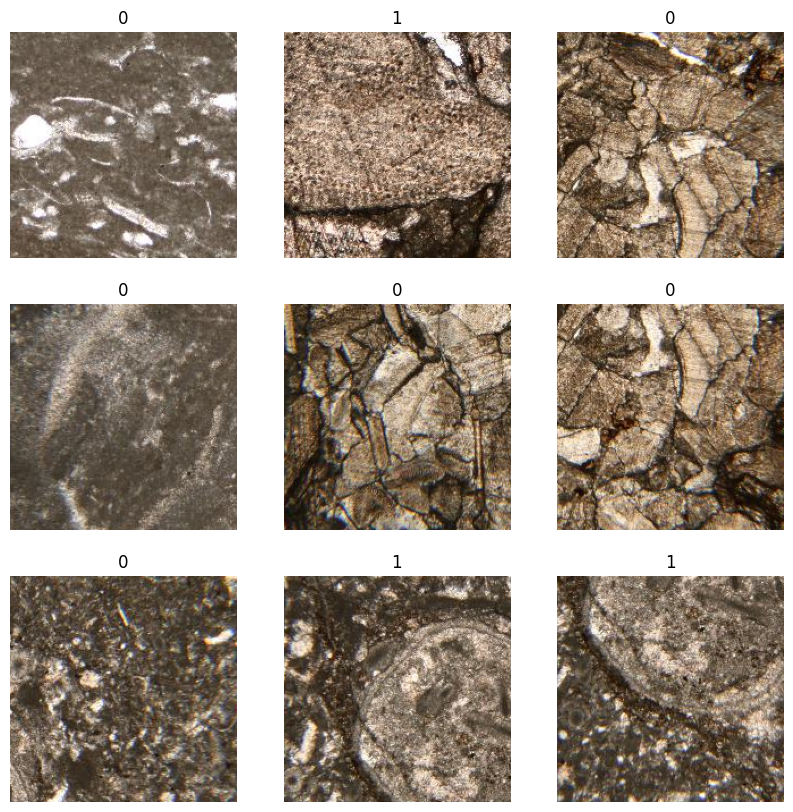

In [10]:

# Shuffle data
training_data = training_data.shuffle(len(Y_train))
validation_data = validation_data.shuffle(len(Y_val))
testing_data = testing_data.shuffle(len(Y_test))

# Verify we did this correctly by plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(testing_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")



We will use transfer learning using different pre-trained models on the imagenet dataset. We first train the Xception model. 

In [11]:
# Our images are already resized, but we could include optional resizing in the final model
# We start with data augmentation
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)
# Create augmented data - Check with Lucy about what we want to do here
#training_data = training_data.map(lambda x, y: (data_augmentation(x), y))

nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

aug_nonfossil_1 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
#aug_nonfossil_2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

training_data = training_data.concatenate(aug_nonfossil_1)
training_data = training_data.concatenate(augfossil)
training_data = training_data.concatenate(augfossil2)

training_data = training_data.shuffle(1000)
#training_data = training_data.concatenate(augmented_data)

# Visualize training data with augmented data
#plt.figure(figsize=(10, 10))
#for i, (image, label) in enumerate(augmented_data.take(9)):
 #   ax = plt.subplot(3, 3, i + 1)
 #   plt.imshow(image)
 #   plt.title(int(label))
 #   plt.axis("off")
#print(augmented_data)

In [12]:
# Batch and prefetch data ?

batch_size = 36 # this could change

training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

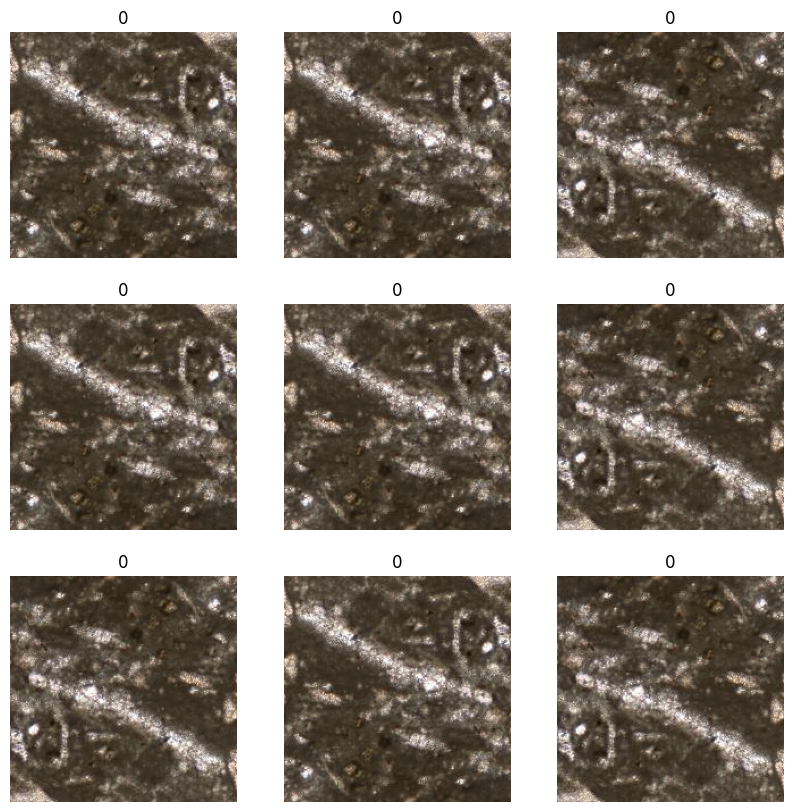

In [13]:
# Visualize augmented data

for images, labels in training_data.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(np.expand_dims(first_image, 0))
        plt.imshow(np.array(augmented_image[0]).astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

In [14]:
# We will use transfer learning using different pre-trained models on the imagenet dataset

# Create the base model with the pre-trained imagenet weights
base_model = keras.applications.Xception(
    weights = 'imagenet',
    input_shape = (200, 200, 3),
    include_top = False) # Why do we not include imagenet at the top? 

# Freeze the base model weights (they will not be trained)

base_model.trainable = False

In [15]:
# Create a new model that goes on top of the base imagenet model
inputs = keras.Input(shape = (200, 200, 3))
# We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
x = scale_layer(inputs)

# We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
# Make sure that base model is running on inference mode

x = base_model(x, training = False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable = True)
# I think we should play with the layers we use here. We should try the setup they have, but maybe add more or different layers depending on how well the model does. 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [16]:
# Train the new top layer of the model
model.compile(
    optimizer = keras.optimizers.Adam(), # play with this also
    loss = keras.losses.BinaryCrossentropy(from_logits = True), #check this also
    metrics = [keras.metrics.BinaryAccuracy()],
)

epochs = 20 # also play with this
print("Fitting top layer of model")
history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Fitting top layer of model
Epoch 1/20
    214/Unknown 82s 270ms/step - binary_accuracy: 0.7932 - loss: 0.4906

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


214/214 ━━━━━━━━━━━━━━━━━━━━ 107s 388ms/step - binary_accuracy: 0.7932 - loss: 0.4904 - val_binary_accuracy: 0.4988 - val_loss: 0.9877
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 74s 161ms/step - binary_accuracy: 0.7791 - loss: 0.4800 - val_binary_accuracy: 0.5535 - val_loss: 0.9569
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - binary_accuracy: 0.7910 - loss: 0.4458 - val_binary_accuracy: 0.5651 - val_loss: 0.9252
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 36s 166ms/step - binary_accuracy: 0.8053 - loss: 0.4204 - val_binary_accuracy: 0.5953 - val_loss: 0.8947
Epoch 5/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 37s 171ms/step - binary_accuracy: 0.8146 - loss: 0.3997 - val_binary_accuracy: 0.6233 - val_loss: 0.8587
Epoch 6/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 36s 169ms/step - binary_accuracy: 0.8184 - loss: 0.3829 - val_binary_accuracy: 0.6349 - val_loss: 0.8511
Epoch 7/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 36s 170ms/step - binary_accuracy: 0.8309 - loss: 0.3681 - val_binary_accuracy: 0.6651 - val_loss: 0.

Note: I don't think two epochs was enough here. This is something we should go through with CV, plotting accuracy and loss over each iteration

In [17]:
# Fine tune entire model
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
    loss = keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()] #check this -- we have a binary model so it should be ok
)

epochs = 3 #??
print("Fitting end-to-end model")
history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 218s 765ms/step - binary_accuracy: 0.7875 - loss: 0.5248 - val_binary_accuracy: 0.8663 - val_loss: 0.3545
Epoch 2/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 124s 581ms/step - binary_accuracy: 0.9682 - loss: 0.1748 - val_binary_accuracy: 1.0000 - val_loss: 0.0649
Epoch 3/3
214/214 ━━━━━━━━━━━━━━━━━━━━ 123s 573ms/step - binary_accuracy: 0.9901 - loss: 0.1003 - val_binary_accuracy: 1.0000 - val_loss: 0.0194


In [18]:
# Validate model on test data
print("Test dataset evaluation:")
test_eval = model.evaluate(testing_data)

Test dataset evaluation:
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - binary_accuracy: 1.0000 - loss: 0.0234


We now test on data that the model has never seen before!

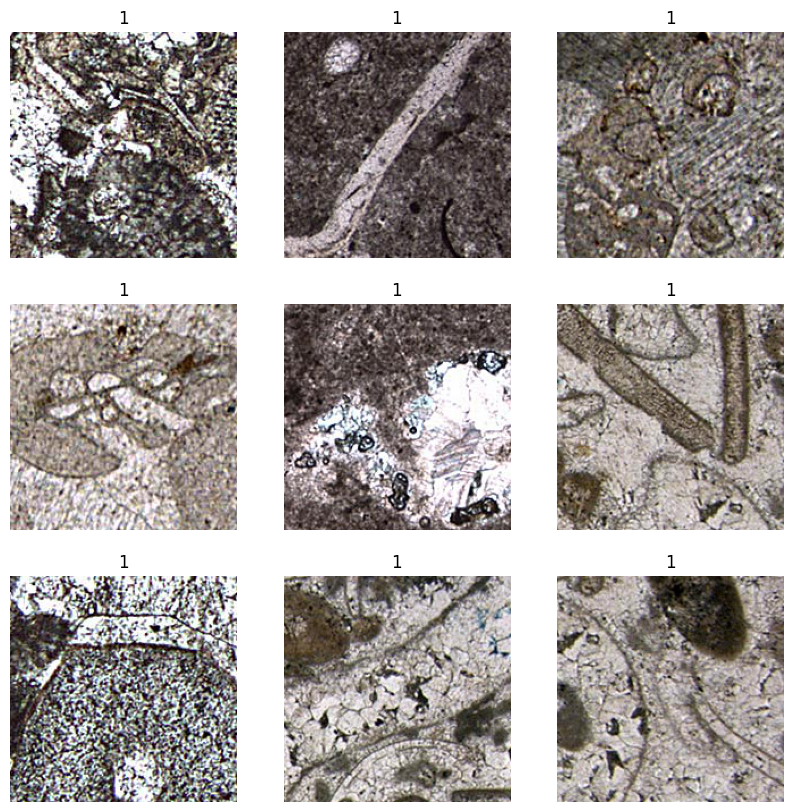

In [19]:
# First, upload and format carbonate world data as testing data
Unseen_CenterFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/CWfossil_center"
Unseen_EdgeFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/CWfossil_edge"
Unseen_NonFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/Carbonate_World_No_Fossil"

Unseen_CenterFossil_Data_Names = []
# Read images 
for filename in os.listdir(Unseen_CenterFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_CenterFossil_Data_Filepath, filename)
        Unseen_CenterFossil_Data_Names.append(filepath)
unseen_test_centerfossil_data = [io.imread(im) for im in Unseen_CenterFossil_Data_Names]
unseen_test_centerfossil_data = np.stack(unseen_test_centerfossil_data)

Unseen_EdgeFossil_Data_Names = []
for filename in os.listdir(Unseen_EdgeFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_EdgeFossil_Data_Filepath, filename)
        Unseen_EdgeFossil_Data_Names.append(filepath)
unseen_test_edgefossil_data = [io.imread(im) for im in Unseen_EdgeFossil_Data_Names]
unseen_test_edgefossil_data = np.stack(unseen_test_edgefossil_data)

Unseen_NonFossil_Data_Names = []
for filename in os.listdir(Unseen_NonFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_NonFossil_Data_Filepath, filename)
        Unseen_NonFossil_Data_Names.append(filepath)
unseen_test_nonfossil_data = [io.imread(im) for im in Unseen_NonFossil_Data_Names]
unseen_test_nonfossil_data = np.stack(unseen_test_nonfossil_data)

unseen_test_vals = np.concatenate([np.ones(unseen_test_centerfossil_data.shape[0]), np.zeros(unseen_test_edgefossil_data.shape[0]), np.zeros(unseen_test_nonfossil_data.shape[0])])
unseen_test_data = np.concatenate([unseen_test_centerfossil_data, unseen_test_edgefossil_data, unseen_test_nonfossil_data])

# Put into correct format
unseen_test_data = tf.data.Dataset.from_tensor_slices((unseen_test_data, unseen_test_vals))

# Verify via plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(unseen_test_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

# Batch
unseen_test_data = unseen_test_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()


In [20]:
print("Unseen Test Data Evaluation:")
unseen_test_eval = model.evaluate(unseen_test_data)

Unseen Test Data Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - binary_accuracy: 0.7248 - loss: 0.8625


Plotting Accuracy and Loss

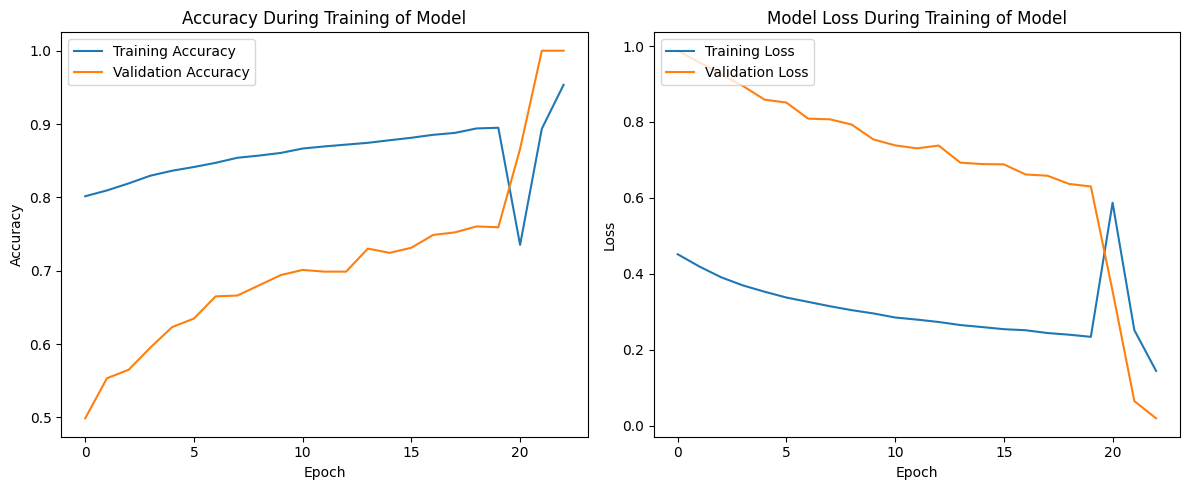

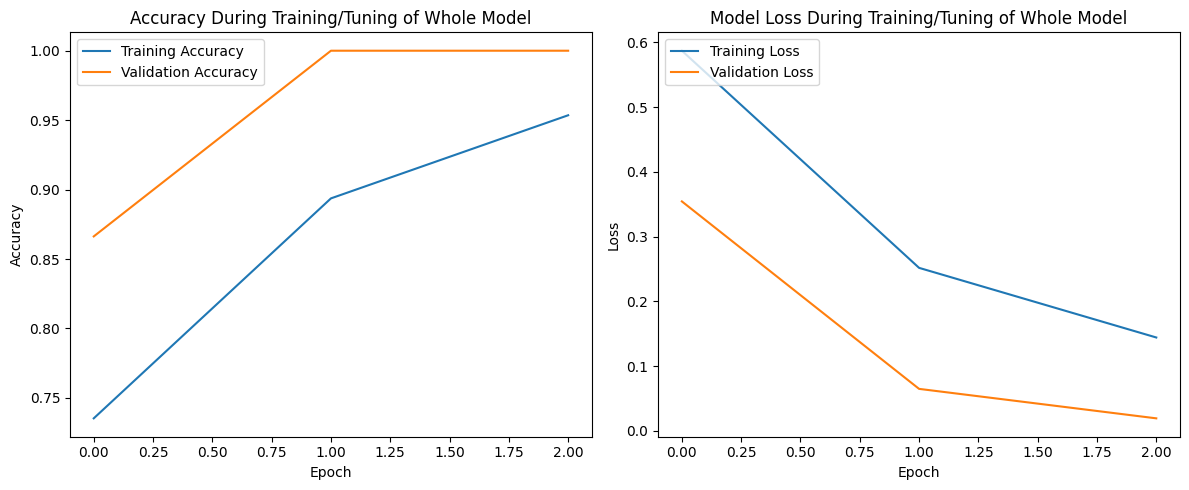

In [21]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label='Training Accuracy')
plt.plot(np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label='Validation Accuracy')
plt.title('Accuracy During Training of Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label='Training Loss')
plt.plot(np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label='Validation Loss')
plt.title('Model Loss During Training of Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_whole_model.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history_whole_model.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Accuracy During Training/Tuning of Whole Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_whole_model.history['loss'], label='Training Loss')
plt.plot(history_whole_model.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training/Tuning of Whole Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [22]:
preds = model.predict(unseen_test_data)
predictions = np.zeros(preds.shape)
for i in range(len(preds)):
    if preds[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
print(predictions)
print(unseen_test_vals)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
[[0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
